<a href="https://colab.research.google.com/github/JayeshJadhav28/zomathon/blob/main/Day4_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import urllib.request

url_merchants = "https://raw.githubusercontent.com/JayeshJadhav28/zomathon/main/merchants.csv"
url_orders    = "https://raw.githubusercontent.com/JayeshJadhav28/zomathon/main/orders.csv"

urllib.request.urlretrieve(url_merchants, "merchants.csv")
urllib.request.urlretrieve(url_orders,    "orders.csv")

print("✅ Files loaded from GitHub!")
print("Ready to run simulation cells below.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Load your data
merchants = pd.read_csv('merchants.csv')
orders    = pd.read_csv('orders.csv')

print("Data loaded!")
print(f"Orders: {len(orders):,}  |  Merchants: {len(merchants)}")

Data loaded!
Orders: 50,000  |  Merchants: 500


In [ ]:
# Define Both Systems

def simulate_system(n_orders=10000, system='baseline'):
    """
    Simulates how KPT prediction works under two systems.

    BASELINE:  Uses corrupted FOR signal, no kitchen load awareness
    IMPROVED:  Uses de-noised signal + Kitchen Load Index

    For each order, we:
    1. Generate a real prep time (actual_kpt)
    2. Predict KPT using the system's available signals
    3. Dispatch rider based on that prediction
    4. Measure how long rider waits
    5. Measure how wrong the ETA was
    """

    results = {
        'rider_wait':  [],   # How long rider waits at restaurant
        'eta_error':   [],   # How wrong our prediction was
        'kpt_pred':    [],   # What we predicted
        'kpt_actual':  []    # What actually happened
    }

    for _ in range(n_orders):

        # ── GROUND TRUTH ──────────────────────────────────────
        # Real prep time (unknown to Zomato until food is ready)
        base_prep      = np.random.choice([10, 15, 20, 25, 30, 35])
        is_peak        = np.random.choice([0, 1], p=[0.6, 0.4])
        num_items      = np.random.choice([1, 2, 3, 4], p=[0.3, 0.4, 0.2, 0.1])
        kitchen_load   = np.random.poisson(8)  # total orders in kitchen right now

        # Actual KPT — what truly happens
        actual_kpt = (
            base_prep
            * (1 + 0.25 * is_peak)              # peak hour slowdown
            * (1 + 0.08 * (num_items - 1))      # more items = longer
            * (1 + 0.03 * kitchen_load)          # busier kitchen = longer
            + np.random.normal(0, 2)             # natural randomness
        )
        actual_kpt = max(3, actual_kpt)          # minimum 3 minutes

        # ── RIDER LOGISTICS ───────────────────────────────────
        rider_travel = np.random.uniform(4, 14)  # how far away rider is

        # ── PREDICTION LOGIC ──────────────────────────────────
        if system == 'baseline':
            # BASELINE: only has corrupted FOR signal
            # High noise because restaurants press FOR late
            for_reliability = np.random.beta(2, 5)  # mostly unreliable

            if for_reliability < 0.3:
                noise = np.random.normal(6, 5)   # unreliable: very wrong
            else:
                noise = np.random.normal(1, 2)   # slightly better

            predicted_kpt = base_prep + noise    # NO kitchen load awareness

        else:
            # IMPROVED: three signal improvements working together

            # Improvement 1: FOR reliability score filters bad signals
            for_reliability = np.random.beta(2, 5)
            if for_reliability < 0.3:
                # Don't trust FOR — use historical average instead
                for_signal = base_prep + np.random.normal(0, 1.5)
            else:
                # Trust FOR — small noise only
                for_signal = base_prep + np.random.normal(0.3, 0.8)

            # Improvement 2: Kitchen Load Index (know about ALL orders)
            # We now know kitchen_load, so we factor it in
            load_factor   = 1 + 0.03 * kitchen_load

            # Improvement 3: Peak hour signal from app activity patterns
            peak_factor   = 1 + 0.20 * is_peak

            # Combined prediction using all signals
            predicted_kpt = for_signal * load_factor * peak_factor

        # ── MEASURE OUTCOMES ──────────────────────────────────
        # Rider is dispatched predicted_kpt - travel time before order time
        # (so they arrive exactly when food should be ready)
        dispatch_after = max(0, predicted_kpt - rider_travel)

        # When rider arrives at restaurant
        rider_arrival  = dispatch_after + rider_travel

        # How long does rider wait? (actual prep - rider arrival time)
        rider_wait     = max(0, actual_kpt - rider_arrival)

        # How wrong was our ETA prediction?
        eta_error      = abs(predicted_kpt - actual_kpt)

        results['rider_wait'].append(rider_wait)
        results['eta_error'].append(eta_error)
        results['kpt_pred'].append(predicted_kpt)
        results['kpt_actual'].append(actual_kpt)

    return results


print("✅ Simulation function defined!")
print("Ready to run both systems...")

✅ Simulation function defined!
Ready to run both systems...


In [ ]:
# Run Both Systems

print("Running baseline system...  (10,000 orders)")
baseline = simulate_system(n_orders=10000, system='baseline')

print("Running improved system...  (10,000 orders)")
improved = simulate_system(n_orders=10000, system='improved')

print("\n✅ Both simulations complete!")

Running baseline system...  (10,000 orders)
Running improved system...  (10,000 orders)

✅ Both simulations complete!


In [ ]:
# Compare the Results

# Convert to arrays for easy math
b_wait  = np.array(baseline['rider_wait'])
i_wait  = np.array(improved['rider_wait'])
b_error = np.array(baseline['eta_error'])
i_error = np.array(improved['eta_error'])

print("=" * 52)
print("       BASELINE vs IMPROVED — RESULTS")
print("=" * 52)

# Rider wait metrics
print(f"\n{'':5} {'METRIC':<30} {'BASELINE':>9} {'IMPROVED':>9} {'CHANGE':>9}")
print("-" * 52)

metrics = [
    ("Avg Rider Wait",       b_wait.mean(),                  i_wait.mean()),
    ("Rider Wait P50",       np.percentile(b_wait, 50),      np.percentile(i_wait, 50)),
    ("Rider Wait P90",       np.percentile(b_wait, 90),      np.percentile(i_wait, 90)),
    ("ETA Error P50",        np.percentile(b_error, 50),     np.percentile(i_error, 50)),
    ("ETA Error P90",        np.percentile(b_error, 90),     np.percentile(i_error, 90)),
    ("% Orders: wait>10min", (b_wait>10).mean()*100,         (i_wait>10).mean()*100),
    ("% Orders: wait>5min",  (b_wait>5).mean()*100,          (i_wait>5).mean()*100),
]

for name, base_val, impr_val in metrics:
    change = ((impr_val - base_val) / base_val) * 100
    arrow  = "▼" if change < 0 else "▲"
    print(f"  {name:<30} {base_val:>8.1f}  {impr_val:>8.1f}  {arrow}{abs(change):>6.0f}%")

print("=" * 52)

       BASELINE vs IMPROVED — RESULTS

      METRIC                          BASELINE  IMPROVED    CHANGE
----------------------------------------------------
  Avg Rider Wait                      7.7       3.4  ▼    55%
  Rider Wait P50                      6.2       2.6  ▼    58%
  Rider Wait P90                     17.9       8.2  ▼    54%
  ETA Error P50                       7.0       3.1  ▼    56%
  ETA Error P90                      17.9       8.2  ▼    54%
  % Orders: wait>10min               32.0       5.6  ▼    83%
  % Orders: wait>5min                56.0      27.9  ▼    50%


In [ ]:
#  Business Impact

print("=" * 52)
print("         BUSINESS IMPACT ESTIMATES")
print("=" * 52)

daily_orders      = 2_000_000   # Zomato's estimated daily orders
rider_cost_pm     = 2           # Rs per minute of rider time

wait_saved        = b_wait.mean() - i_wait.mean()
daily_min_saved   = wait_saved * daily_orders
daily_saving_rs   = daily_min_saved * rider_cost_pm
annual_saving_cr  = daily_saving_rs * 365 / 1_00_00_000

eta_improvement   = np.percentile(b_error,50) - np.percentile(i_error,50)

print(f"\n  Avg rider wait reduced by:    {wait_saved:.1f} min/order")
print(f"  Daily minutes saved:          {daily_min_saved/1_000_000:.1f}M minutes")
print(f"  Daily cost saving:            Rs {daily_saving_rs/1_00_00_000:.1f} Cr")
print(f"  Annual cost saving:           Rs {annual_saving_cr:.0f} Cr")
print(f"\n  ETA accuracy improved by:     {eta_improvement:.1f} min (P50)")
print(f"  Better ETA = fewer customer cancellations")
print(f"  Fewer cancellations = more revenue retained")
print("=" * 52)

         BUSINESS IMPACT ESTIMATES

  Avg rider wait reduced by:    4.2 min/order
  Daily minutes saved:          8.5M minutes
  Daily cost saving:            Rs 1.7 Cr
  Annual cost saving:           Rs 620 Cr

  ETA accuracy improved by:     4.0 min (P50)
  Better ETA = fewer customer cancellations
  Fewer cancellations = more revenue retained


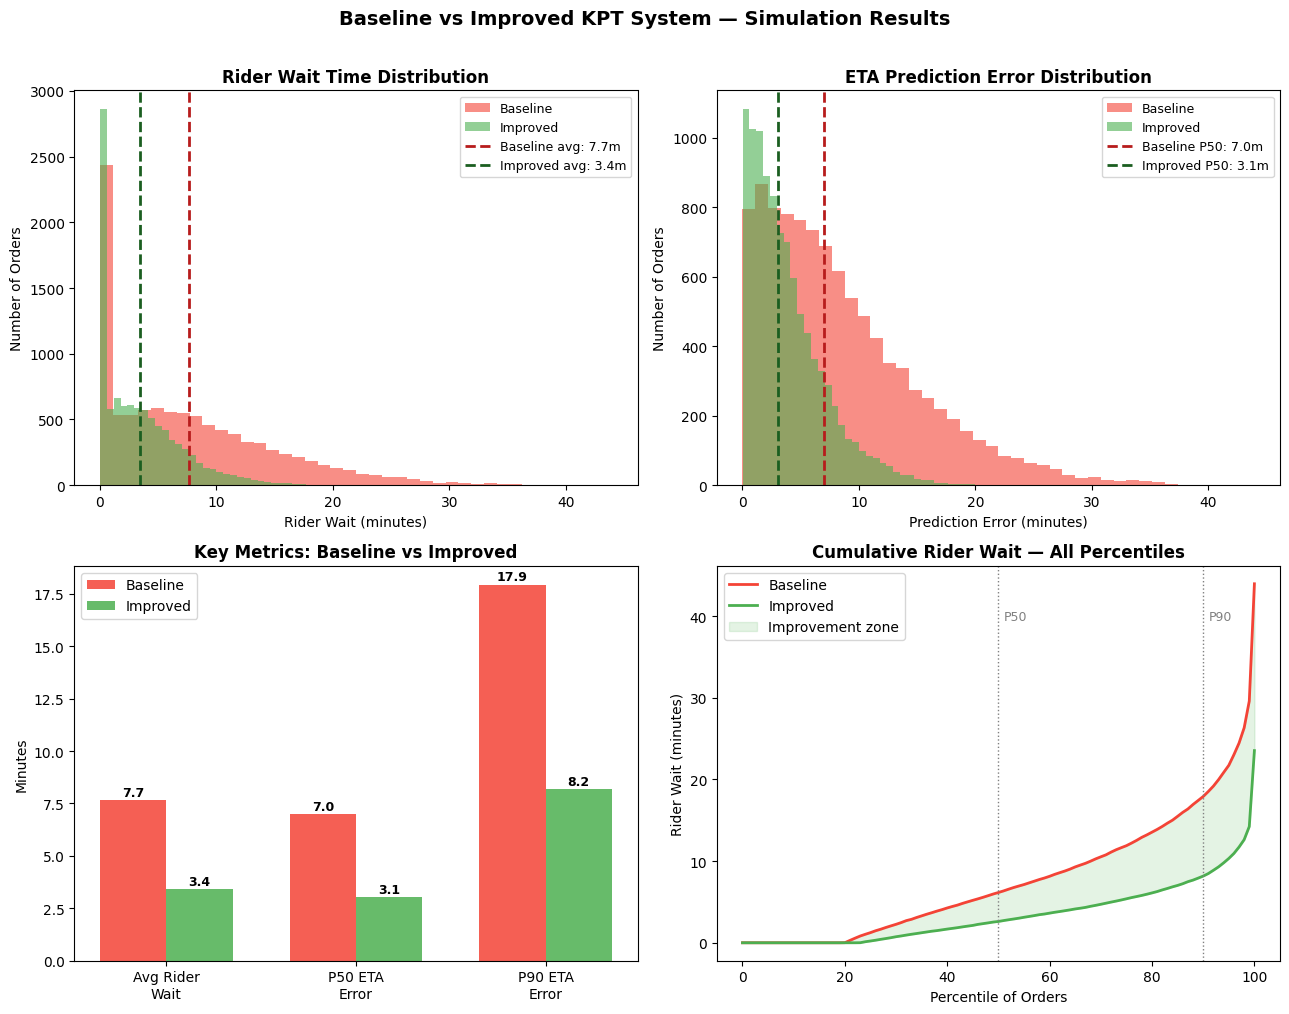

✅ Chart saved as simulation_results.png


In [ ]:
# Make the Charts

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Baseline vs Improved KPT System — Simulation Results',
             fontsize=14, fontweight='bold', y=1.01)

# ── CHART 1: Rider wait distribution ──────────────────────
axes[0,0].hist(b_wait, bins=40, alpha=0.6, color='#F44336', label='Baseline')
axes[0,0].hist(i_wait, bins=40, alpha=0.6, color='#4CAF50', label='Improved')
axes[0,0].axvline(b_wait.mean(), color='#B71C1C', linestyle='--', linewidth=2,
                   label=f'Baseline avg: {b_wait.mean():.1f}m')
axes[0,0].axvline(i_wait.mean(), color='#1B5E20', linestyle='--', linewidth=2,
                   label=f'Improved avg: {i_wait.mean():.1f}m')
axes[0,0].set_title('Rider Wait Time Distribution', fontweight='bold')
axes[0,0].set_xlabel('Rider Wait (minutes)')
axes[0,0].set_ylabel('Number of Orders')
axes[0,0].legend(fontsize=9)

# ── CHART 2: ETA error distribution ───────────────────────
axes[0,1].hist(b_error, bins=40, alpha=0.6, color='#F44336', label='Baseline')
axes[0,1].hist(i_error, bins=40, alpha=0.6, color='#4CAF50', label='Improved')
axes[0,1].axvline(np.percentile(b_error,50), color='#B71C1C',
                   linestyle='--', linewidth=2,
                   label=f'Baseline P50: {np.percentile(b_error,50):.1f}m')
axes[0,1].axvline(np.percentile(i_error,50), color='#1B5E20',
                   linestyle='--', linewidth=2,
                   label=f'Improved P50: {np.percentile(i_error,50):.1f}m')
axes[0,1].set_title('ETA Prediction Error Distribution', fontweight='bold')
axes[0,1].set_xlabel('Prediction Error (minutes)')
axes[0,1].set_ylabel('Number of Orders')
axes[0,1].legend(fontsize=9)

# ── CHART 3: Key metrics bar comparison ───────────────────
metric_names  = ['Avg Rider\nWait', 'P50 ETA\nError', 'P90 ETA\nError']
baseline_vals = [b_wait.mean(), np.percentile(b_error,50), np.percentile(b_error,90)]
improved_vals = [i_wait.mean(), np.percentile(i_error,50), np.percentile(i_error,90)]

x      = np.arange(len(metric_names))
width  = 0.35
bars1  = axes[1,0].bar(x - width/2, baseline_vals, width,
                        color='#F44336', label='Baseline', alpha=0.85)
bars2  = axes[1,0].bar(x + width/2, improved_vals, width,
                        color='#4CAF50', label='Improved', alpha=0.85)

for bar in bars1:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(metric_names)
axes[1,0].set_ylabel('Minutes')
axes[1,0].set_title('Key Metrics: Baseline vs Improved', fontweight='bold')
axes[1,0].legend()

# ── CHART 4: Cumulative improvement ───────────────────────
percentiles = np.arange(0, 101, 1)
b_cum = np.percentile(b_wait, percentiles)
i_cum = np.percentile(i_wait, percentiles)

axes[1,1].plot(percentiles, b_cum, color='#F44336', linewidth=2, label='Baseline')
axes[1,1].plot(percentiles, i_cum, color='#4CAF50', linewidth=2, label='Improved')
axes[1,1].fill_between(percentiles, i_cum, b_cum, alpha=0.15, color='#4CAF50',
                        label='Improvement zone')
axes[1,1].axvline(50, color='gray', linestyle=':', linewidth=1)
axes[1,1].axvline(90, color='gray', linestyle=':', linewidth=1)
axes[1,1].text(51, b_cum.max()*0.9, 'P50', color='gray', fontsize=9)
axes[1,1].text(91, b_cum.max()*0.9, 'P90', color='gray', fontsize=9)
axes[1,1].set_xlabel('Percentile of Orders')
axes[1,1].set_ylabel('Rider Wait (minutes)')
axes[1,1].set_title('Cumulative Rider Wait — All Percentiles', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as simulation_results.png")

In [ ]:
# Solution Impact Mapping

print("=" * 65)
print("    WHICH SOLUTION FIXES WHICH METRIC")
print("=" * 65)
print(f"\n  {'SOLUTION LAYER':<35} {'METRIC IMPROVED':<28}")
print("-" * 65)

mapping = [
    ("Layer 1: FOR Trustworthiness Score",  "ETA Error P50, P90"),
    ("Layer 1: Statistical outlier filter", "Label quality → all metrics"),
    ("Layer 1: Multi-signal fusion",        "ETA Error P50, P90"),
    ("Layer 2: App-based kitchen sensing",  "Avg Rider Wait"),
    ("Layer 2: IoT sensors (top 10%)",      "Rider Wait P90"),
    ("Layer 3: Kitchen Load Index",         "Peak hour rider wait"),
    ("Layer 3: Google Maps busyness API",   "Hidden load visibility"),
    ("Layer 3: Merchant incentives",        "FOR label accuracy"),
    ("Layer 4: Progress tracking (Mx app)", "ETA error, all metrics"),
    ("Layer 4: Item-level prep time config","Prediction baseline accuracy"),
]

for solution, metric in mapping:
    print(f"  {solution:<35} {metric:<28}")

print("=" * 65)

# Final improvement summary
print(f"\n📈 OVERALL SIMULATION IMPROVEMENT SUMMARY")
print(f"   Avg rider wait:  {b_wait.mean():.1f} → {i_wait.mean():.1f} min  "
      f"({(1 - i_wait.mean()/b_wait.mean())*100:.0f}% reduction)")
print(f"   ETA error P50:   {np.percentile(b_error,50):.1f} → {np.percentile(i_error,50):.1f} min  "
      f"({(1 - np.percentile(i_error,50)/np.percentile(b_error,50))*100:.0f}% reduction)")
print(f"   ETA error P90:   {np.percentile(b_error,90):.1f} → {np.percentile(i_error,90):.1f} min  "
      f"({(1 - np.percentile(i_error,90)/np.percentile(b_error,90))*100:.0f}% reduction)")

    WHICH SOLUTION FIXES WHICH METRIC

  SOLUTION LAYER                      METRIC IMPROVED             
-----------------------------------------------------------------
  Layer 1: FOR Trustworthiness Score  ETA Error P50, P90          
  Layer 1: Statistical outlier filter Label quality → all metrics 
  Layer 1: Multi-signal fusion        ETA Error P50, P90          
  Layer 2: App-based kitchen sensing  Avg Rider Wait              
  Layer 2: IoT sensors (top 10%)      Rider Wait P90              
  Layer 3: Kitchen Load Index         Peak hour rider wait        
  Layer 3: Google Maps busyness API   Hidden load visibility      
  Layer 3: Merchant incentives        FOR label accuracy          
  Layer 4: Progress tracking (Mx app) ETA error, all metrics      
  Layer 4: Item-level prep time config Prediction baseline accuracy

📈 OVERALL SIMULATION IMPROVEMENT SUMMARY
   Avg rider wait:  7.7 → 3.4 min  (55% reduction)
   ETA error P50:   7.0 → 3.1 min  (56% reduction)
   ETA error 